# FIFA World Cup Prediction Model
## Notebook 04 — Tournament Simulation

**Goal:** Load the trained ensemble model and run 100,000 Monte Carlo simulations of the 2026 World Cup to estimate each team's championship probability.

### How Monte Carlo simulation works
Instead of predicting one fixed outcome, we simulate the entire tournament thousands of times — each time letting match results vary according to the model's probabilities. The fraction of simulations a team wins = their estimated championship probability.


In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings

from src.elo import EloSystem
from src.features import build_features, FEATURE_COLS
from src.simulate import run_simulation, GROUPS_2026, simulate_match

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (13, 6)})

os.makedirs(os.path.join('..', 'outputs'), exist_ok=True)
print('Imports OK ✓')


Imports OK ✓


## 1. Load trained ensemble model

In [3]:
ensemble = joblib.load(os.path.join('..', 'models', 'ensemble_model.pkl'))
print('Ensemble model loaded ✓')
print(f'Weights: Poisson={ensemble.weights[0]:.2f}, XGBoost={ensemble.weights[1]:.2f}, RF={ensemble.weights[2]:.2f}, LR={ensemble.weights[3]:.2f}')


Ensemble model loaded ✓
Weights: Poisson=0.35, XGBoost=0.30, RF=0.20, LR=0.15


## 2. Load current ELO ratings & form stats

In [4]:
matches = pd.read_csv(
    os.path.join('..', 'data', 'processed', 'matches_modern.csv'),
    parse_dates=['date']
).sort_values('date').reset_index(drop=True)
matches = matches.dropna(subset=['home_score', 'away_score']).reset_index(drop=True)

# Rebuild ELO on full history
elo = EloSystem(default_elo=1500, home_advantage=100)
elo.fit(matches, verbose=False)
elo_ratings = elo.ratings

print(f'ELO ratings computed for {len(elo_ratings)} teams')
print()
print('Top 15 current ELO ratings:')
print(elo.top_n(15).round(1).to_string())


ELO ratings computed for 326 teams

Top 15 current ELO ratings:
Spain          2202.5
Argentina      2144.1
France         2106.7
England        2091.6
Brazil         2040.8
Ecuador        2038.1
Colombia       2033.0
Japan          2013.3
Portugal       1997.7
Morocco        1992.5
Norway         1987.1
Netherlands    1984.3
Germany        1983.0
Turkey         1975.0
Uruguay        1957.9


In [5]:
# Build current form stats for all teams
from src.features import compute_form

today = pd.Timestamp('today')
form_stats = {}
all_teams = [team for group in GROUPS_2026.values() for team in group]

for team in all_teams:
    form_stats[team] = compute_form(matches, team, before_date=today, window=10)

print('Form stats computed ✓')
print()
print('Sample — Brazil form:')
print(form_stats.get('Brazil', 'Not found'))


Form stats computed ✓

Sample — Brazil form:
{'form_ppg': np.float64(1.9), 'goals_scored': np.float64(2.5), 'goals_conceded': np.float64(1.1), 'win_rate': np.float64(0.6), 'days_since_last': 9, 'n_matches': 10}


## 3. Verify team names match the dataset

Team names in `GROUPS_2026` must match names in the match results dataset exactly.
Run this cell to catch any mismatches and fix them in `src/simulate.py`.


In [6]:
known_teams = set(pd.concat([matches.home_team, matches.away_team]).unique())
missing = [t for t in all_teams if t not in known_teams]

if missing:
    print(f'⚠️  These team names are NOT in the dataset — update GROUPS_2026 in src/simulate.py:')
    for t in missing:
        print(f'   {t}')
else:
    print('All team names match dataset ✓')


All team names match dataset ✓


## 4. Single match prediction — sanity check

In [7]:
def predict_match(home, away, n=10000):
    """Estimate win probabilities via Monte Carlo for a single match."""
    home_wins, draws, away_wins = 0, 0, 0
    for _ in range(n):
        result, _, _ = simulate_match(
            home, away, ensemble, elo_ratings, form_stats,
            is_neutral=True, allow_draw=True
        )
        if result == home:   home_wins += 1
        elif result == away: away_wins += 1
        else:                draws += 1
    print(f'{home:20s} vs {away:20s}')
    print(f'  {home} win: {home_wins/n*100:.1f}%')
    print(f'  Draw:       {draws/n*100:.1f}%')
    print(f'  {away} win: {away_wins/n*100:.1f}%')
    print()

predict_match('Brazil', 'Argentina')
predict_match('France', 'England')
predict_match('Germany', 'Spain')


Brazil               vs Argentina           
  Brazil win: 29.2%
  Draw:       26.2%
  Argentina win: 44.5%

France               vs England             
  France win: 39.0%
  Draw:       26.2%
  England win: 34.8%

Germany              vs Spain               
  Germany win: 27.9%
  Draw:       26.5%
  Spain win: 45.6%



## 5. Run 100,000 tournament simulations

This takes ~3–8 minutes. Each simulation plays out the entire 2026 World Cup —
group stage through to the final — using probabilistic match outcomes.


In [8]:
import importlib, src.simulate
importlib.reload(src.simulate)
from src.simulate import run_simulation, GROUPS_2026

results = run_simulation(
    model=ensemble,
    elo_ratings=elo_ratings,
    form_stats=form_stats,
    n_simulations=100_000,
    use_real_elo=True,
)

print()
print('=== 2026 World Cup Championship Probabilities ===')
print()
print(results.head(20).to_string(index=False))

2026-06-15 01:11:02 [INFO] src.simulate: Pre-computing team stats...
2026-06-15 01:11:02 [INFO] src.simulate: Pre-computing Poisson lambdas...
2026-06-15 01:11:02 [INFO] src.simulate: Pre-computing Poisson lambdas for 48 teams...
2026-06-15 01:11:02 [INFO] src.simulate: Pre-computed 2,256 matchup lambdas ✓
2026-06-15 01:11:02 [INFO] src.simulate: Running 100,000 simulations...
Simulating: 100%|██████████| 100000/100000 [00:31<00:00, 3215.47it/s]



=== 2026 World Cup Championship Probabilities ===

       team  win_pct  final_pct  semifinal_pct  quarterfinal_pct  r16_pct  r32_pct
      Spain   16.266     23.305         33.759            49.684   78.432   99.107
  Argentina   11.601     17.496         26.391            39.813   71.495   97.486
    England    8.282     13.323         20.935            38.861   66.531   97.983
     France    6.545     11.201         18.647            34.048   62.174   94.885
   Portugal    4.534      8.191         15.953            30.770   57.300   94.796
    Belgium    4.236      9.089         17.952            32.822   58.119   97.351
    Germany    3.710      6.750         15.177            28.889   54.795   94.759
Netherlands    3.303      6.304         14.125            27.484   54.349   95.137
     Brazil    3.297      6.427         12.757            26.382   53.576   94.471
   Colombia    3.247      6.366         12.773            24.201   47.472   86.198
    Morocco    3.036      6.972    

In [9]:
out_path = os.path.join('..', 'outputs', 'wc2026_predictions.csv')
results.to_csv(out_path, index=False)
print(f'Saved → {out_path}')


Saved → ../outputs/wc2026_predictions.csv


## 6. Visualise results

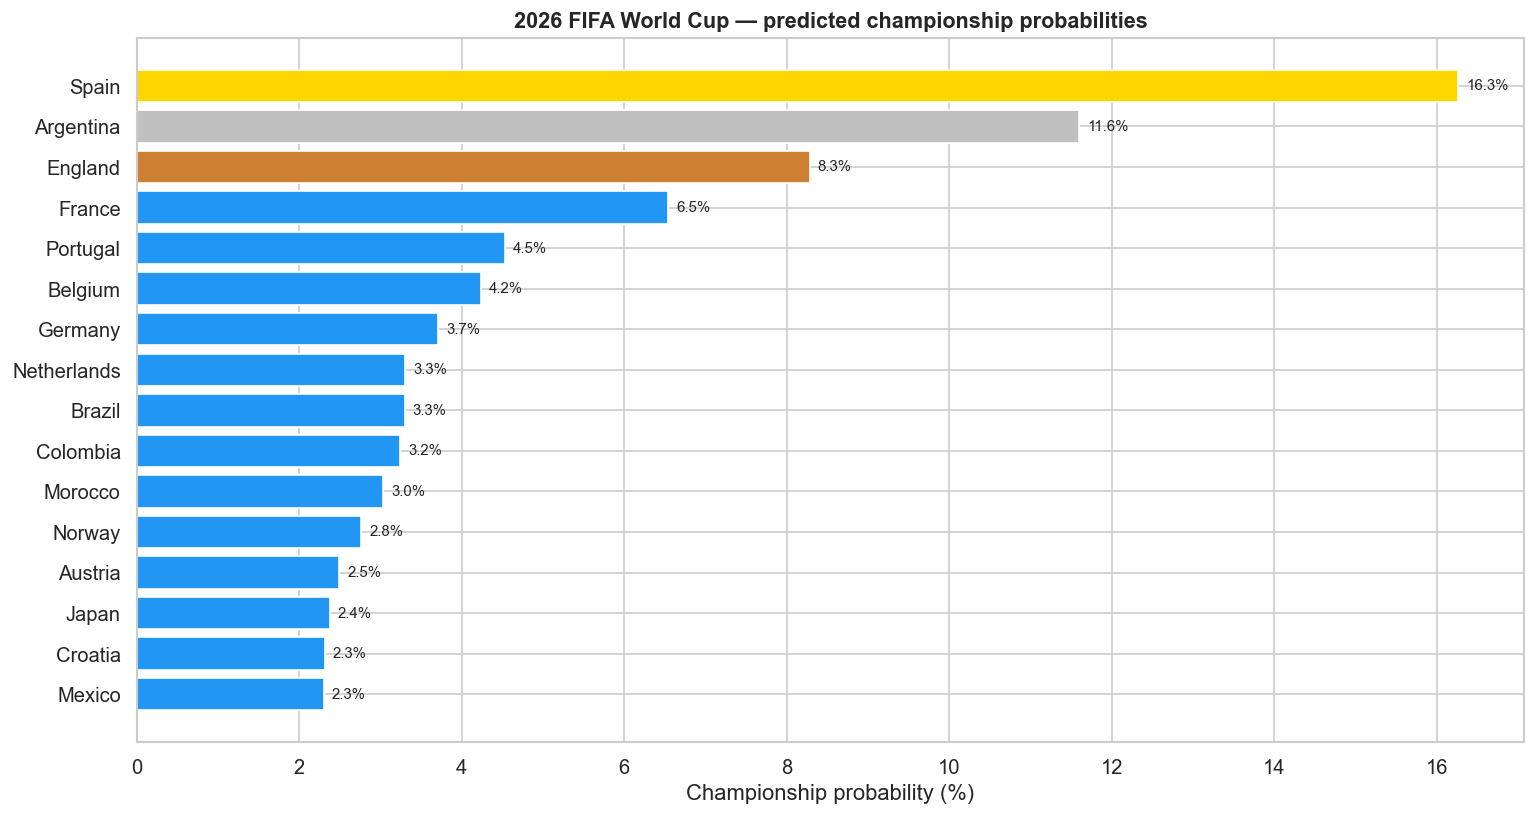

In [10]:
# Championship probability — top 16
top16 = results.head(16)

fig, ax = plt.subplots(figsize=(13, 7))
colors = ['#FFD700' if i == 0 else '#C0C0C0' if i == 1 else '#CD7F32' if i == 2 else '#2196F3'
          for i in range(len(top16))]
bars = ax.barh(top16.team[::-1], top16.win_pct[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Championship probability (%)')
ax.set_title('2026 FIFA World Cup — predicted championship probabilities', fontweight='bold', fontsize=13)
ax.axvline(0, color='black', lw=0.5)
for bar, val in zip(bars, top16.win_pct[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'wc2026_championship_probs.png'), bbox_inches='tight')
plt.show()


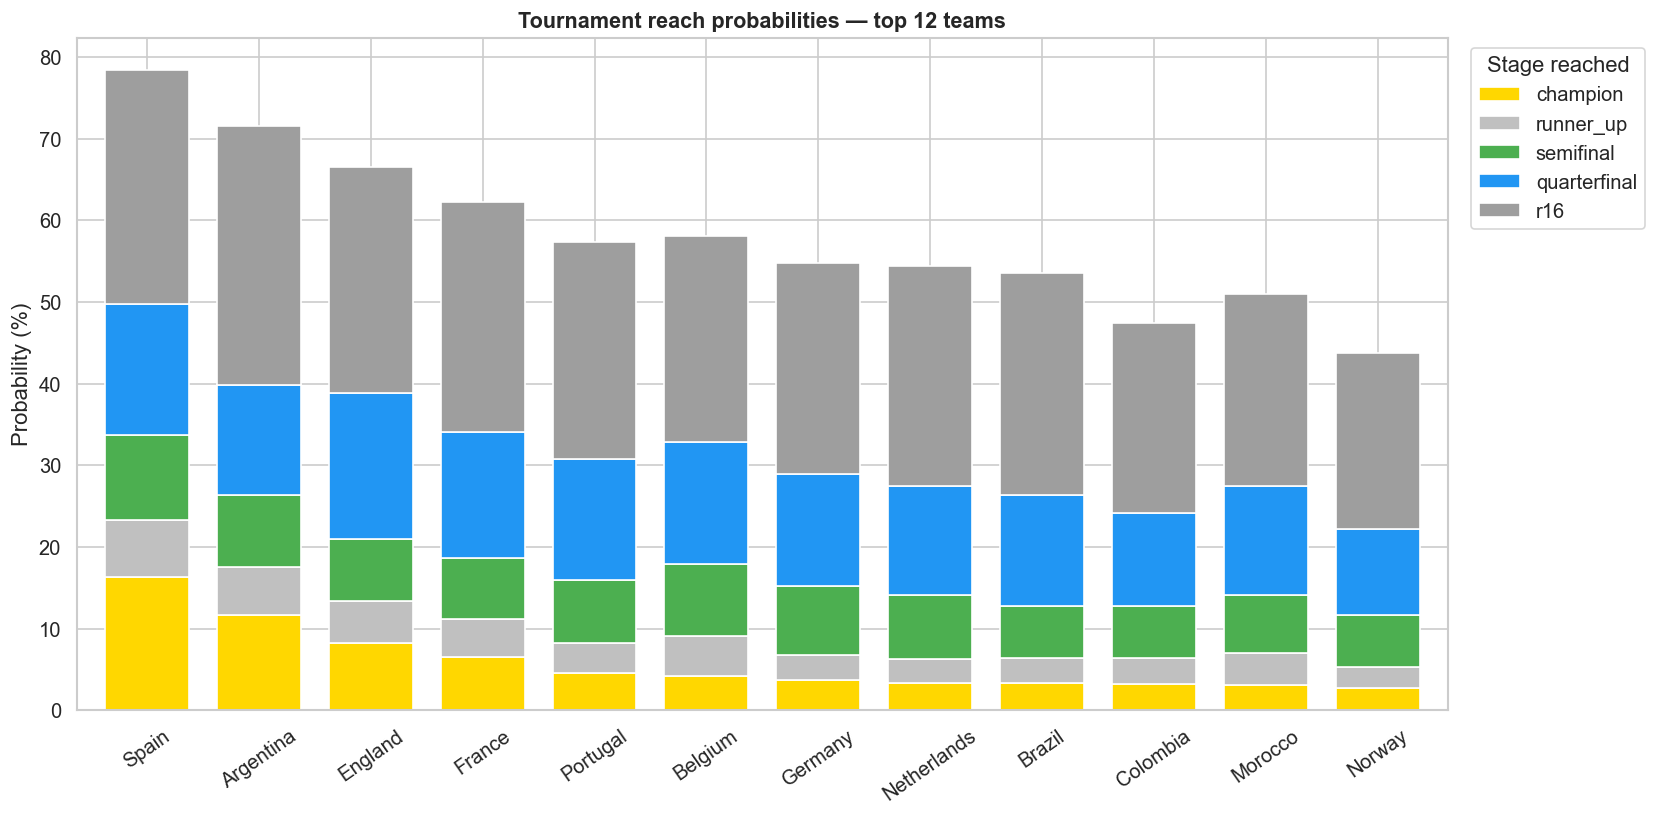

In [11]:
# Stacked bar: win / final / semi / quarter probabilities for top 12
top12 = results.head(12).copy()
top12 = top12.set_index('team')

# Convert to marginal (just-that-round) probabilities
top12['champion']     = top12['win_pct']
top12['runner_up']    = top12['final_pct']        - top12['win_pct']
top12['semifinal']    = top12['semifinal_pct']    - top12['final_pct']
top12['quarterfinal'] = top12['quarterfinal_pct'] - top12['semifinal_pct']
top12['r16']          = top12['r16_pct']          - top12['quarterfinal_pct']

plot_cols = ['champion', 'runner_up', 'semifinal', 'quarterfinal', 'r16']
plot_colors = ['#FFD700', '#C0C0C0', '#4CAF50', '#2196F3', '#9E9E9E']

fig, ax = plt.subplots(figsize=(14, 7))
top12[plot_cols].plot(kind='bar', stacked=True, ax=ax, color=plot_colors, edgecolor='white', width=0.75)
ax.set_xlabel('')
ax.set_ylabel('Probability (%)')
ax.set_title('Tournament reach probabilities — top 12 teams', fontweight='bold', fontsize=13)
ax.legend(title='Stage reached', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'wc2026_stage_probs.png'), bbox_inches='tight')
plt.show()


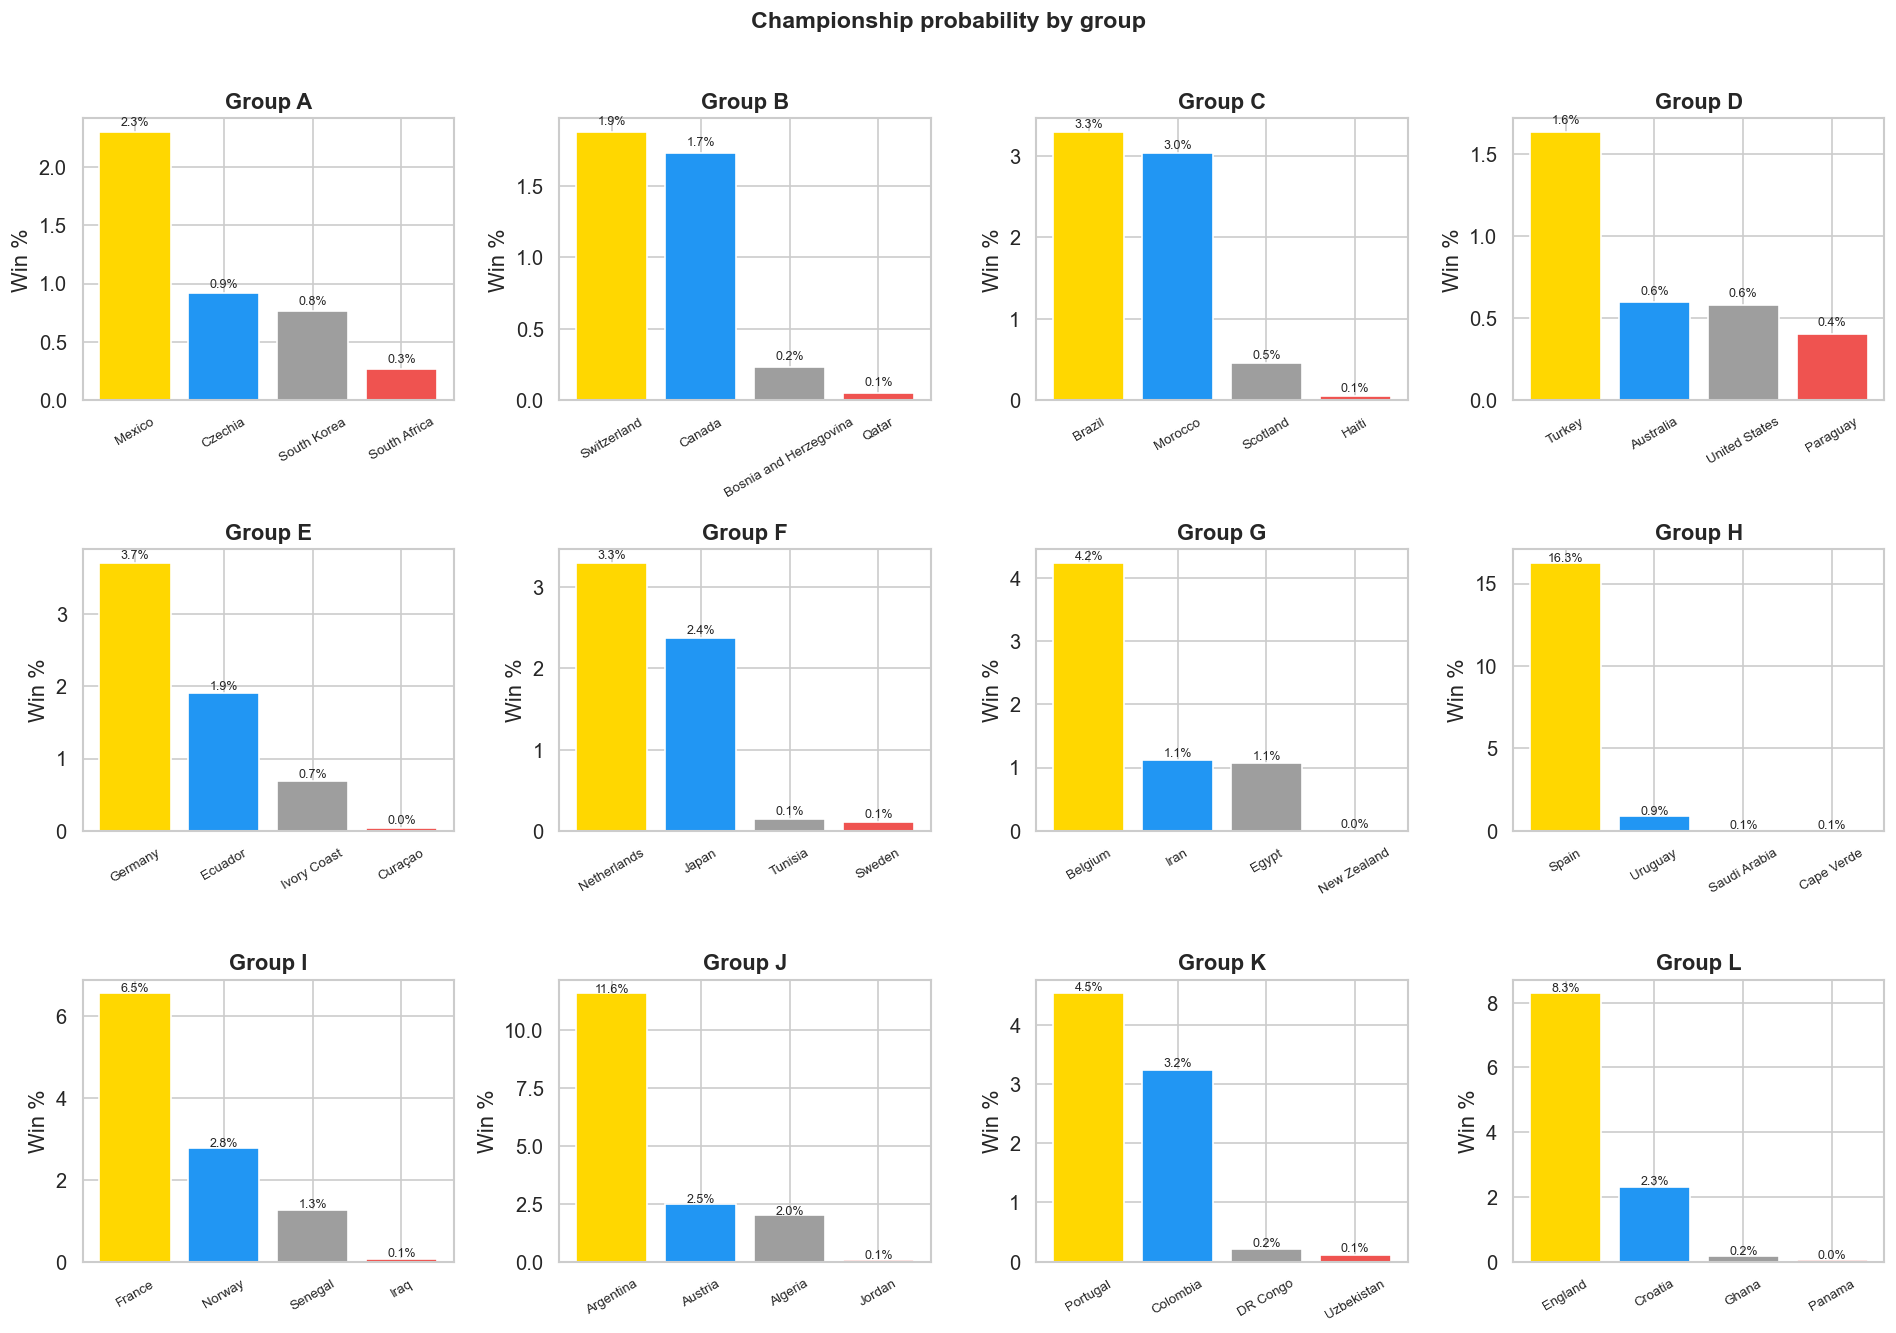

In [12]:
# Group-by-group breakdown
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.flatten()

for idx, (gname, teams) in enumerate(GROUPS_2026.items()):
    ax = axes[idx]
    group_data = results[results.team.isin(teams)].sort_values('win_pct', ascending=False)
    bars = ax.bar(group_data.team, group_data.win_pct,
                  color=['#FFD700','#2196F3','#9E9E9E','#EF5350'], edgecolor='white')
    ax.set_title(f'Group {gname}', fontweight='bold')
    ax.set_ylabel('Win %')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    for bar, val in zip(bars, group_data.win_pct):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.1f}%', ha='center', fontsize=7.5)

plt.suptitle('Championship probability by group', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'wc2026_by_group.png'), bbox_inches='tight')
plt.show()


In [13]:
out_path = os.path.join('..', 'outputs', 'wc2026_predictions.csv')
results.to_csv(out_path, index=False)
print(f'Saved → {out_path}')

Saved → ../outputs/wc2026_predictions.csv


## ✅ Simulation complete

### Outputs saved
| File | Description |
|---|---|
| `outputs/wc2026_predictions.csv` | Full probability table for all 48 teams |
| `outputs/wc2026_championship_probs.png` | Top 16 championship probabilities |
| `outputs/wc2026_stage_probs.png` | Stacked stage-reach chart |
| `outputs/wc2026_by_group.png` | Group-by-group breakdown |

### How to improve the model further
- Tune ensemble weights by optimising log-loss on a validation set
- Add squad availability features (injuries, suspensions)
- Fine-tune on World Cup–only matches (higher K-factor data)
